In [10]:
# Library imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    recall_score
)


In [11]:
# 1) Load the dataset
data = '../data/raw/creditcard.csv'
df = pd.read_csv(data)

# 2) Separate features (X) and target (y)
X = df.drop("Class", axis=1)
y = df["Class"]

# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 4) Feature scaling (important since features like 'Amount' vary widely)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5) Train logistic regression model
logreg = LogisticRegression(C=0.1, max_iter=1000, class_weight="balanced") # Class-weight is balanced to give more weight for under-represented class.
logreg.fit(X_train_scaled, y_train)

# 6) Predict on test set
y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1] #predicting probability of each class to compute AUC

# 7) Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred)) # Measure to Minimize False Positivies
print("Recall:", recall_score(y_test, y_pred))  # Measure to Minimize False negatives, used to assess model performance when false negatives are costly such as Credit card Fraud.
print("ROC-AUC:", roc_auc_score(y_test, y_proba)) # Trade-off between Accuracy & Recall (Sensitivity)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9786875460833538
Recall: 0.8783783783783784
ROC-AUC: 0.9681506789631533

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.07      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.56     85443
weighted avg       1.00      0.98      0.99     85443


Confusion Matrix:

[[83492  1803]
 [   18   130]]


In [12]:
# Get feature names
feature_names = X.columns

# Get coefficients
coefficients = logreg.coef_[0]

# Create a DataFrame for easier viewing
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": abs(coefficients)
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient", ascending=False
)

print(feature_importance.head(10))

   Feature  Coefficient  Absolute_Coefficient
10     V10    -1.736331              1.736331
4       V4     1.658765              1.658765
1       V1     1.565455              1.565455
14     V14    -1.320073              1.320073
12     V12    -1.120766              1.120766
29  Amount     1.029965              1.029965
17     V17    -0.827253              0.827253
9       V9    -0.819272              0.819272
5       V5     0.760282              0.760282
16     V16    -0.757263              0.757263


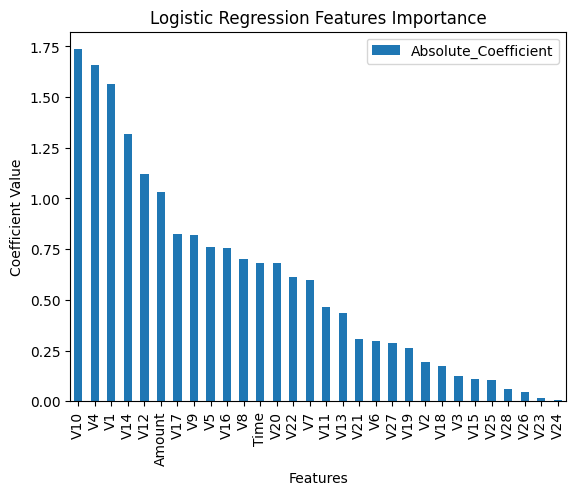

In [13]:
# Plotting feature importance with coefficient values.
feature_importance.plot(x="Feature", y="Absolute_Coefficient", kind="bar")

plt.title("Logistic Regression Features Importance")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")

plt.show()

## The Feature importance from Logistic Regression aligns with Box Whisker Plots in Exploratory Analysis.
## We have used 'balanced' class weight in Logistic Regression Model & Stratified sampling to address class imbalance.
## The Models sensitivity/ Recall in fraud detection is about 88% , meaning the model still can produce False negatives that can be improved by either increasing the Fraudlent training data set and using methods like cross validation. 